# Molecular toxicity prediction with a graph neural network
### A scaffold-separated, multi-assay benchmark on real Tox21 data

**Question:** Can a small molecule graph network match a strong Morgan-fingerprint baseline when the test molecules have different scaffolds from the training molecules?

This notebook joins cheminformatics, neural message passing, missing-label learning, and careful evaluation. It trains a native PyTorch GNN and twelve fingerprint classifiers on the **same molecules and the same split**, then reports the comparison without assuming the neural model wins.

**Deliverable:** an executed, self-contained research notebook with real data provenance, audit checks, learning curves, assay-level results, and a paired uncertainty analysis.

## Scientific scope

Tox21 measures activity in twelve nuclear-receptor (NR) and stress-response (SR) assays. The labels describe experimental assay responses, **not a patient's diagnosis or a molecule's clinical safety**. A positive label is assay activity; a negative label is measured inactivity; a missing label means unmeasured, not safe.

The model is a small screening research prototype. These in-vitro endpoints omit dose, exposure, metabolism, organ-level effects, and clinical context. They cannot establish that a chemical is safe for people. The useful portfolio contribution is the reproducible comparison under a harder chemical-generalization split.

## Run from a fresh Python environment

Run all cells in order. The only external artifact is the public compressed Tox21 CSV, downloaded into `.tox21_cache` in the current directory. `TOX21_DATA_DIR` can point to an existing cache. A pinned SHA-256 digest verifies that reruns use the same bytes. All feature generation, batching, models, and evaluation are defined below; no local modules, checkpoints, or external graph framework are required.

The optional installation cell is commented out. CPU training uses two threads, a fixed seed, and fifteen epochs at most. Exact values can still vary across dependency versions and CPU implementations; the version table records the executed environment.

In [1]:
# Optional setup for a fresh environment; uncomment before the first run.
# %pip install numpy pandas matplotlib scikit-learn requests rdkit torch

In [2]:
import os, sys, json, random, hashlib, copy, time, platform
from pathlib import Path
from collections import defaultdict
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import requests
from IPython.display import display, Markdown
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import torch
from torch import nn
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')
plt.rcParams.update({'figure.dpi': 125, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
RDLogger.DisableLog('rdApp.error')  # Invalid rows are counted explicitly below.

In [3]:
versions = {name: metadata.version(name) for name in
            ['numpy', 'pandas', 'matplotlib', 'scikit-learn', 'requests', 'rdkit', 'torch']}
display(pd.Series({'Python': platform.python_version(), **versions}, name='version').to_frame())
print(f'Seed={SEED}; device={DEVICE}; PyTorch threads={torch.get_num_threads()}')

,version
Python,3.12.14
numpy,2.3.5
pandas,2.2.3
matplotlib,3.10.8
scikit-learn,1.8.0
requests,2.34.2
rdkit,2026.3.6
torch,2.5.1+cpu


Seed=42; device=cpu; PyTorch threads=2


## 1. Download, verify, and inspect the experimental labels

The public [DeepChem Tox21 CSV](https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz) is the data artifact used here. Tox21 is part of [MoleculeNet](https://doi.org/10.1039/C7SC02664A); the original program is described by the [NIH Tox21 overview](https://ncats.nih.gov/research/research-activities/tox21).

The digest below identifies this exact compressed file. A changed or corrupted cache raises an error rather than silently changing the benchmark. Network failures stop execution; there is no synthetic fallback.

In [4]:
DATA_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz'
EXPECTED_SHA256 = '45d09792492ce049039dd24aa27b07fc79ce20c573187d4d90bcd178c0c0d360'
CACHE_DIR = Path(os.environ.get('TOX21_DATA_DIR', str(Path.cwd() / '.tox21_cache')))
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = CACHE_DIR / 'tox21.csv.gz'
if not DATA_PATH.exists():
    response = requests.get(DATA_URL, timeout=(15, 120))
    response.raise_for_status()
    temporary = DATA_PATH.with_suffix('.download')
    temporary.write_bytes(response.content)
    if hashlib.sha256(temporary.read_bytes()).hexdigest() != EXPECTED_SHA256:
        temporary.unlink()
        raise ValueError('Downloaded Tox21 bytes do not match the pinned SHA-256.')
    temporary.replace(DATA_PATH)
data_sha = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert data_sha == EXPECTED_SHA256, 'Cache digest mismatch: inspect or replace the cache.'
raw = pd.read_csv(DATA_PATH)
TASKS = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
         'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
assert set(TASKS + ['smiles', 'mol_id']).issubset(raw.columns)
assert set(raw[TASKS].stack().unique()).issubset({0.0, 1.0})
provenance = {'source_url': DATA_URL, 'sha256': data_sha, 'compressed_bytes': DATA_PATH.stat().st_size,
              'raw_rows': len(raw), 'endpoints': len(TASKS)}
print(json.dumps(provenance, indent=2))
display(raw.head(3))

{
  "source_url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz",
  "sha256": "45d09792492ce049039dd24aa27b07fc79ce20c573187d4d90bcd178c0c0d360",
  "compressed_bytes": 122925,
  "raw_rows": 7831,
  "endpoints": 12
}


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...


## 2. Convert SMILES into valid, tractable molecular graphs

RDKit parses and sanitizes each SMILES. For a disconnected structure, this benchmark retains the fragment with the largest heavy-atom count; ties use canonical SMILES. This strips counterions but can change the experimental substance, so the number affected is reported. Formal charge and stereochemistry are otherwise retained in the molecule.

Rows with invalid structures, zero heavy atoms, or more than 100 heavy atoms are excluded. The last limit is a declared CPU-budget constraint, not a toxicity rule. Rows with no observed assay labels are also excluded. Duplicate canonical structures are retained as separate experimental rows; the scaffold grouping keeps them together, preventing copies from crossing the split. This does not turn repeated measurements into independent experiments.

{
  "retained_rows": 7816,
  "excluded_rows": {
    "zero_or_over_100_heavy_atoms": 7,
    "invalid_or_unsanitizable_smiles": 8
  },
  "disconnected_rows_encountered": 244,
  "retained_duplicate_structure_rows": 115,
  "largest_retained_heavy_atom_count": 100
}


,mol_id,source_row,canonical_smiles,heavy_atoms
0,TOX3021,0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,16
1,TOX3020,1,CCN1C(=O)NC(c2ccccc2)C1=O,15
2,TOX3024,2,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,21
3,TOX3027,3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,20
4,TOX20800,4,CC(O)(P(=O)(O)O)P(=O)(O)O,11


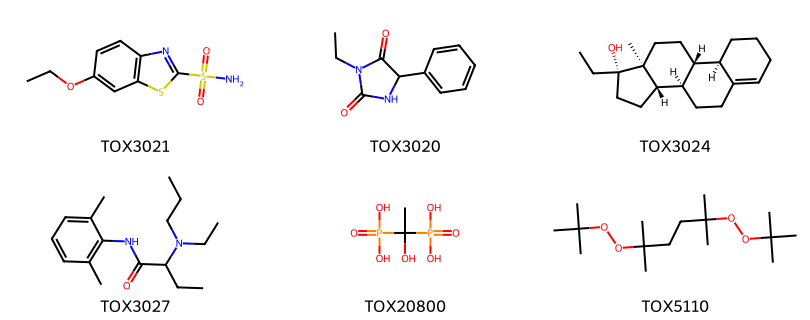

In [5]:
MAX_HEAVY_ATOMS = 100
molecules, records = [], []
exclusions = defaultdict(int)
fragment_changes = 0
for source_row, row in raw.iterrows():
    mol = Chem.MolFromSmiles(str(row['smiles']))
    if mol is None:
        exclusions['invalid_or_unsanitizable_smiles'] += 1
        continue
    fragments = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    if len(fragments) > 1:
        fragment_changes += 1
        mol = sorted(fragments, key=lambda m: (-m.GetNumHeavyAtoms(), Chem.MolToSmiles(m)))[0]
    atoms = mol.GetNumHeavyAtoms()
    if atoms == 0 or atoms > MAX_HEAVY_ATOMS:
        exclusions['zero_or_over_100_heavy_atoms'] += 1
        continue
    if row[TASKS].isna().all():
        exclusions['no_observed_assay_labels'] += 1
        continue
    item = row.to_dict()
    item.update(source_row=int(source_row), canonical_smiles=Chem.MolToSmiles(mol), heavy_atoms=atoms)
    records.append(item)
    molecules.append(mol)

data = pd.DataFrame(records).reset_index(drop=True)
labels = data[TASKS].to_numpy(dtype=np.float32)  # NaN remains explicit until masking.
assert len(data) + sum(exclusions.values()) == len(raw)
assert len(molecules) == len(labels)
qc = {'retained_rows': len(data), 'excluded_rows': dict(exclusions),
      'disconnected_rows_encountered': fragment_changes,
      'retained_duplicate_structure_rows': int(data['canonical_smiles'].duplicated().sum()),
      'largest_retained_heavy_atom_count': int(data['heavy_atoms'].max())}
print(json.dumps(qc, indent=2))
display(data[['mol_id', 'source_row', 'canonical_smiles', 'heavy_atoms']].head())
display(Draw.MolsToGridImage(molecules[:6], molsPerRow=3, subImgSize=(270, 160),
                            legends=data['mol_id'].head(6).tolist()))

,observed,positive,missing_fraction,positive_fraction_among_observed
NR-AR,7251,306,0.072,0.042
NR-AR-LBD,6744,237,0.137,0.035
NR-AhR,6535,767,0.164,0.117
NR-Aromatase,5810,300,0.257,0.052
NR-ER,6179,791,0.209,0.128
NR-ER-LBD,6942,349,0.112,0.050
NR-PPAR-gamma,6440,185,0.176,0.029
SR-ARE,5824,941,0.255,0.162
SR-ATAD5,7059,262,0.097,0.037
SR-HSE,6460,372,0.173,0.058


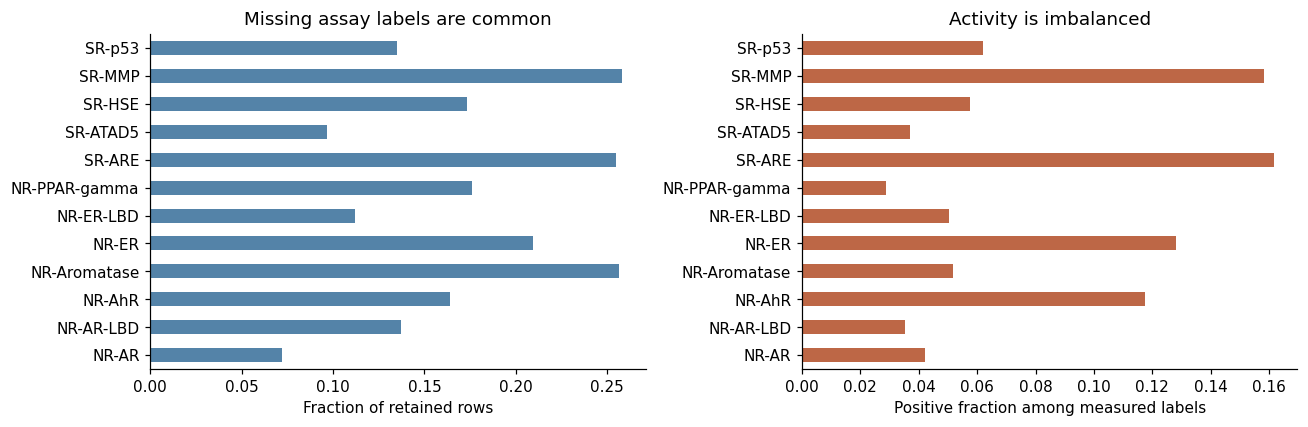

In [6]:
label_audit = pd.DataFrame({
    'observed': np.isfinite(labels).sum(axis=0),
    'positive': np.nansum(labels, axis=0).astype(int),
    'missing_fraction': np.isnan(labels).mean(axis=0)}, index=TASKS)
label_audit['positive_fraction_among_observed'] = label_audit['positive'] / label_audit['observed']
display(label_audit.round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
label_audit['missing_fraction'].plot.barh(ax=ax[0], color='#5483a8')
label_audit['positive_fraction_among_observed'].plot.barh(ax=ax[1], color='#bd6746')
ax[0].set(title='Missing assay labels are common', xlabel='Fraction of retained rows')
ax[1].set(title='Activity is imbalanced', xlabel='Positive fraction among measured labels')
fig.tight_layout()
plt.show()

## 3. Separate scaffold families before learning anything

A random row split often places close analogues in both training and test sets. Here each molecule receives an RDKit **Bemis–Murcko scaffold**: its ring systems and linkers. Every scaffold stays in one partition. All acyclic molecules share the empty scaffold, an intentionally strict grouping that can dominate a partition. Chirality is ignored in the scaffold key so stereochemical variants cannot cross partitions by that route.

Groups are shuffled with a fixed seed, then assigned largest-first toward 80% training, 10% validation, and 10% test rows. The exact sizes can deviate because groups are indivisible. This is one deterministic scaffold split, not a temporal validation or a guarantee of all chemical novelty: different scaffolds can still share substructures.

Only training labels determine class weights. Validation selects the GNN epoch. Test labels are audited for class support, but never used for fitting or model selection. Test model performance is evaluated after selection ends.

In [7]:
scaffolds = [MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False) for m in molecules]
groups = defaultdict(list)
for index, scaffold in enumerate(scaffolds):
    groups[scaffold].append(index)
group_keys = list(groups)
np.random.default_rng(SEED).shuffle(group_keys)
group_keys.sort(key=lambda key: len(groups[key]), reverse=True)
train_idx, val_idx, test_idx = [], [], []
train_limit, val_limit = int(0.8 * len(data)), int(0.1 * len(data))
for key in group_keys:
    group = groups[key]
    if len(train_idx) + len(group) <= train_limit:
        train_idx.extend(group)
    elif len(val_idx) + len(group) <= val_limit:
        val_idx.extend(group)
    else:
        test_idx.extend(group)
train_idx, val_idx, test_idx = map(lambda rows: np.array(sorted(rows), dtype=int),
                                  [train_idx, val_idx, test_idx])
splits = {'train': train_idx, 'validation': val_idx, 'test': test_idx}
scaffold_sets = {name: set(np.array(scaffolds)[rows]) for name, rows in splits.items()}
assert not (scaffold_sets['train'] & scaffold_sets['validation'])
assert not (scaffold_sets['train'] & scaffold_sets['test'])
assert not (scaffold_sets['validation'] & scaffold_sets['test'])
assert len(set(np.concatenate(list(splits.values())))) == len(data)
assert sum(map(len, splits.values())) == len(data)
canonical_sets = {name: set(data.iloc[rows]['canonical_smiles']) for name, rows in splits.items()}
assert not (canonical_sets['train'] & canonical_sets['test'])
assert not (canonical_sets['train'] & canonical_sets['validation'])
assert not (canonical_sets['validation'] & canonical_sets['test'])
split_summary = pd.DataFrame([
    {'partition': name, 'rows': len(rows), 'fraction': len(rows)/len(data),
     'scaffolds': len(scaffold_sets[name]), 'observed_labels': int(np.isfinite(labels[rows]).sum())}
    for name, rows in splits.items()]).set_index('partition')
display(split_summary.round(3))
print('Scaffold and canonical-structure disjointness checks passed.')
print('Largest scaffold group:', max(map(len, groups.values())), 'rows; acyclic group:', len(groups.get('', [])))

,rows,fraction,scaffolds,observed_labels
partition,,,,
train,6252,0.8,714,63598
validation,781,0.1,781,7161
test,783,0.1,783,7044


Scaffold and canonical-structure disjointness checks passed.
Largest scaffold group: 1791 rows; acyclic group: 1791


In [8]:
support = pd.DataFrame(index=TASKS)
for name, rows in splits.items():
    support[f'{name}_observed'] = np.isfinite(labels[rows]).sum(axis=0)
    support[f'{name}_positive'] = np.nansum(labels[rows], axis=0).astype(int)
    support[f'{name}_negative'] = support[f'{name}_observed'] - support[f'{name}_positive']
display(support)
assert (support['train_positive'] > 0).all() and (support['train_negative'] > 0).all()
split_digest = hashlib.sha256(json.dumps({name: data.iloc[rows]['source_row'].tolist()
                                        for name, rows in splits.items()}, sort_keys=True).encode()).hexdigest()
print('Split-row SHA-256:', split_digest)

,train_observed,train_positive,train_negative,validation_observed,validation_positive,validation_negative,test_observed,test_positive,test_negative
NR-AR,5829,251,5578,718,26,692,704,29,675
NR-AR-LBD,5502,194,5308,635,25,610,607,18,589
NR-AhR,5303,579,4724,631,98,533,601,90,511
NR-Aromatase,4788,210,4578,509,43,466,513,47,466
NR-ER,5082,645,4437,560,73,487,537,73,464
NR-ER-LBD,5633,296,5337,661,23,638,648,30,618
NR-PPAR-gamma,5289,135,5154,587,22,565,564,28,536
SR-ARE,4871,716,4155,464,119,345,489,106,383
SR-ATAD5,5728,196,5532,670,30,640,661,36,625
SR-HSE,5309,283,5026,553,42,511,598,47,551


Split-row SHA-256: e6ac489f02cf2d3d694447b61e02a453a0a74ff6686e6765abef90b1e9f9cd9e


## 4. Two representations of the same molecular rows

The baseline uses radius-2, 2,048-bit Morgan fingerprints and a balanced logistic regression for each assay. It is a serious low-cost molecular model: local chemical substructures are encoded directly, and regularized linear fitting is efficient on a dataset of this size. `C=1` is fixed in advance; no test-based tuning occurs.

The GNN receives atom features and explicit bond features. Three message-passing steps learn local environments, then mean pooling plus molecule size produce a shared representation for twelve output logits. Its atom features include element, degree, hybridization, formal charge, hydrogen count, aromaticity, and ring membership. The graph model does **not** encode chirality or bond stereochemistry as features; this is a representation limitation even though canonical structure identities retain stereochemistry.

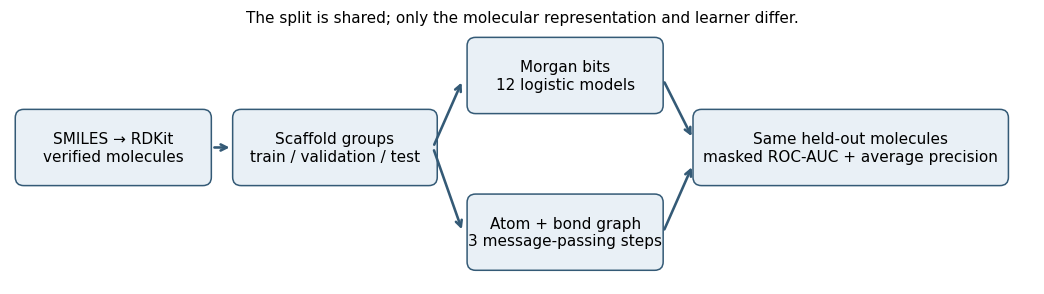

In [9]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.set(xlim=(0, 12), ylim=(0, 3.2)); ax.axis('off')
boxes = [(0.15, 1.25, 2.1, 'SMILES → RDKit\nverified molecules'),
         (2.7, 1.25, 2.2, 'Scaffold groups\ntrain / validation / test'),
         (5.45, 2.1, 2.1, 'Morgan bits\n12 logistic models'),
         (5.45, 0.25, 2.1, 'Atom + bond graph\n3 message-passing steps'),
         (8.1, 1.25, 3.5, 'Same held-out molecules\nmasked ROC-AUC + average precision')]
for x, y, w, label in boxes:
    ax.add_patch(FancyBboxPatch((x, y), w, .7, boxstyle='round,pad=.1',
                                facecolor='#e9f0f6', edgecolor='#345a76'))
    ax.text(x+w/2, y+.35, label, ha='center', va='center', fontsize=10)
for start, end in [((2.35,1.6),(2.6,1.6)), ((4.95,1.6),(5.3,2.4)),
                   ((4.95,1.6),(5.3,.6)), ((7.65,2.4),(8,1.7)), ((7.65,.6),(8,1.4))]:
    ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':'#345a76','lw':1.7})
ax.text(6, 3.08, 'The split is shared; only the molecular representation and learner differ.', ha='center')
plt.show()

In [10]:
ELEMENTS = [6, 7, 8, 9, 15, 16, 17, 35, 53]
HYBRIDIZATIONS = [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
                  Chem.rdchem.HybridizationType.SP3]
BOND_TYPES = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
              Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]
def one_hot_unknown(value, options):
    return [float(value == option) for option in options] + [float(value not in options)]
def atom_features(atom):
    return (one_hot_unknown(atom.GetAtomicNum(), ELEMENTS)
            + one_hot_unknown(atom.GetDegree(), list(range(6)))
            + one_hot_unknown(atom.GetHybridization(), HYBRIDIZATIONS)
            + [float(atom.GetFormalCharge())/3, atom.GetTotalNumHs()/4,
               float(atom.GetIsAromatic()), float(atom.IsInRing())])
def molecule_graph(mol):
    atom_x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float32)
    source, target, edge_x = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        features = one_hot_unknown(bond.GetBondType(), BOND_TYPES) + [float(bond.GetIsConjugated()), float(bond.IsInRing())]
        source.extend([i, j]); target.extend([j, i]); edge_x.extend([features, features])
    edge_index = torch.tensor([source, target], dtype=torch.long)
    edge_attr = torch.tensor(edge_x, dtype=torch.float32).reshape(-1, len(BOND_TYPES)+3)
    return {'x': atom_x, 'edge_index': edge_index, 'edge_attr': edge_attr}

graphs = [molecule_graph(mol) for mol in molecules]
fingerprint_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fingerprints = np.zeros((len(data), 2048), dtype=np.uint8)
for index, mol in enumerate(molecules):
    DataStructs.ConvertToNumpyArray(fingerprint_generator.GetFingerprint(mol), fingerprints[index])
ATOM_DIM = graphs[0]['x'].shape[1]
EDGE_DIM = graphs[0]['edge_attr'].shape[1]
assert all(g['x'].shape[0] == m.GetNumAtoms() for g, m in zip(graphs, molecules))
assert fingerprints.shape[0] == len(graphs) == labels.shape[0]
print(f'Graph features: {ATOM_DIM} per atom, {EDGE_DIM} per directed bond; fingerprint matrix: {fingerprints.shape}')

Graph features: 25 per atom, 7 per directed bond; fingerprint matrix: (7816, 2048)


## 5. Metric contract and the fingerprint reference

ROC-AUC measures positive–negative ranking. Average precision (AP) summarizes the precision–recall curve and is especially relevant when positives are rare. AP's prevalence reference is the observed positive fraction in that partition; this reference is reported per assay. Neither metric measures probability calibration.

Each assay is scored only on its observed labels. If a partition has only one observed class, its ROC-AUC and AP comparison are marked missing and omitted from the macro average. Macro averaging weights assays equally, regardless of assay size. No classification threshold is selected or applied in this benchmark.

In [11]:
def evaluate_assays(y_true, probabilities):
    rows = []
    for task_index, task in enumerate(TASKS):
        observed = np.isfinite(y_true[:, task_index])
        truth = y_true[observed, task_index]
        score = probabilities[observed, task_index]
        has_two_classes = len(np.unique(truth)) == 2
        rows.append({'assay': task, 'observed': len(truth), 'positive': int(truth.sum()),
                     'prevalence': float(truth.mean()) if len(truth) else np.nan,
                     'roc_auc': roc_auc_score(truth, score) if has_two_classes else np.nan,
                     'average_precision': average_precision_score(truth, score) if has_two_classes else np.nan})
    return pd.DataFrame(rows).set_index('assay')
def macro_metrics(table):
    return {'macro_roc_auc': float(table['roc_auc'].mean()),
            'macro_average_precision': float(table['average_precision'].mean()),
            'eligible_assays': int(table['roc_auc'].notna().sum())}

baseline_models = []
for task_index, task in enumerate(TASKS):
    observed_rows = train_idx[np.isfinite(labels[train_idx, task_index])]
    classifier = LogisticRegression(C=1.0, class_weight='balanced', solver='liblinear',
                                    max_iter=1000, random_state=SEED)
    classifier.fit(fingerprints[observed_rows], labels[observed_rows, task_index])
    baseline_models.append(classifier)
def baseline_predict(rows):
    return np.column_stack([model.predict_proba(fingerprints[rows])[:, 1] for model in baseline_models])
baseline_val_probabilities = baseline_predict(val_idx)
baseline_val_table = evaluate_assays(labels[val_idx], baseline_val_probabilities)
print('Fingerprint validation:', json.dumps(macro_metrics(baseline_val_table), indent=2))

Fingerprint validation: {
  "macro_roc_auc": 0.6892534252085373,
  "macro_average_precision": 0.27309669473407444,
  "eligible_assays": 12
}


## 6. Native PyTorch message passing

For a directed bond \(j\to i\), a learned MLP transforms the source atom state and bond features into a message. Incoming messages are averaged at atom \(i\). A second MLP updates its state through a residual connection and layer normalization. Repeating this three times makes each atom responsive to a local neighborhood. Mean graph pooling and log atom count feed a shared multi-task prediction head.

Batching concatenates atoms and offsets bond indices; a `graph_id` vector keeps molecules separate. Molecules with no bonds receive zero neighbor messages. This explicit implementation avoids a dependency on PyTorch Geometric and makes the graph mechanics inspectable.

In [12]:
def collate_graphs(row_indices):
    xs, edge_indices, edge_attributes, graph_ids = [], [], [], []
    offset = 0
    for batch_index, row_index in enumerate(row_indices):
        graph = graphs[int(row_index)]
        xs.append(graph['x'])
        edge_indices.append(graph['edge_index'] + offset)
        edge_attributes.append(graph['edge_attr'])
        graph_ids.append(torch.full((len(graph['x']),), batch_index, dtype=torch.long))
        offset += len(graph['x'])
    y = torch.tensor(labels[np.array(row_indices, dtype=int)], dtype=torch.float32)
    return {'x': torch.cat(xs), 'edge_index': torch.cat(edge_indices, dim=1),
            'edge_attr': torch.cat(edge_attributes), 'graph_id': torch.cat(graph_ids),
            'y': torch.nan_to_num(y, nan=0.0), 'mask': torch.isfinite(y),
            'n_graphs': len(row_indices)}

class MessageLayer(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.message = nn.Sequential(nn.Linear(hidden + EDGE_DIM, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.update = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.ReLU(), nn.Dropout(.15), nn.Linear(hidden, hidden))
        self.norm = nn.LayerNorm(hidden)
    def forward(self, h, edge_index, edge_attr):
        source, target = edge_index
        aggregate = torch.zeros_like(h)
        degree = h.new_zeros((len(h), 1))
        if source.numel():
            messages = self.message(torch.cat([h[source], edge_attr], dim=1))
            aggregate.index_add_(0, target, messages)
            degree.index_add_(0, target, torch.ones((len(target), 1), dtype=h.dtype))
        aggregate = aggregate / degree.clamp(min=1)
        return torch.relu(self.norm(h + self.update(torch.cat([h, aggregate], dim=1))))

class ToxicityGNN(nn.Module):
    def __init__(self, hidden=48, depth=3):
        super().__init__()
        self.encode = nn.Sequential(nn.Linear(ATOM_DIM, hidden), nn.ReLU())
        self.layers = nn.ModuleList([MessageLayer(hidden) for _ in range(depth)])
        self.head = nn.Sequential(nn.Linear(hidden + 1, hidden), nn.ReLU(), nn.Dropout(.2), nn.Linear(hidden, len(TASKS)))
    def forward(self, batch):
        h = self.encode(batch['x'])
        for layer in self.layers:
            h = layer(h, batch['edge_index'], batch['edge_attr'])
        pooled = h.new_zeros((batch['n_graphs'], h.shape[1]))
        pooled.index_add_(0, batch['graph_id'], h)
        counts = torch.bincount(batch['graph_id'], minlength=batch['n_graphs']).float().unsqueeze(1)
        pooled = torch.cat([pooled / counts, torch.log1p(counts)/5], dim=1)
        return self.head(pooled)

def graph_loader(rows, shuffle=False):
    return DataLoader(rows.tolist(), batch_size=96, shuffle=shuffle, collate_fn=collate_graphs,
                      num_workers=0, generator=torch.Generator().manual_seed(SEED))
def graph_predict(model, rows):
    model.eval()
    with torch.no_grad():
        return np.concatenate([torch.sigmoid(model(batch)).numpy() for batch in graph_loader(rows)])

model = ToxicityGNN().to(DEVICE)
print('Trainable GNN parameters:', sum(p.numel() for p in model.parameters()))
sample_batch = next(iter(graph_loader(train_idx[:5])))
assert model(sample_batch).shape == (5, len(TASKS))
print('Graph batching/output shape check passed.')

Trainable GNN parameters: 40668
Graph batching/output shape check passed.


## 7. Masked, weighted training with validation-only early stopping

The loss is binary cross entropy with logits. Missing targets are replaced only for tensor storage and multiplied by an explicit mask, so their loss contribution is zero. Positive-class weights are the training negative/positive ratio for each assay. These weights emphasize rare active compounds; the resulting sigmoid scores should not be interpreted as calibrated activity probabilities.

Adam uses a fixed learning rate of 0.001 and weight decay of 0.0001. Gradients are clipped to 5. The best epoch is selected by **validation macro ROC-AUC** with patience four, up to fifteen epochs. No architecture search is performed. Weighted loss is averaged over observed labels, so assays with more observations can contribute more training signal even though evaluation gives assays equal macro weight.

In [13]:
train_y = labels[train_idx]
positive_counts = np.nansum(train_y, axis=0)
negative_counts = np.isfinite(train_y).sum(axis=0) - positive_counts
pos_weight = torch.tensor(negative_counts / positive_counts, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=.001, weight_decay=.0001)
MAX_EPOCHS, PATIENCE = 15, 4
best_score, best_epoch, stalled, best_state = -np.inf, 0, 0, None
history, started = [], time.perf_counter()
train_loader = graph_loader(train_idx, shuffle=True)
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    loss_total, label_total = 0.0, 0
    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        logits = model(batch)
        per_label_loss = criterion(logits, batch['y'])
        loss = (per_label_loss * batch['mask']).sum() / batch['mask'].sum()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        loss_total += float((per_label_loss.detach() * batch['mask']).sum())
        label_total += int(batch['mask'].sum())
    validation_table = evaluate_assays(labels[val_idx], graph_predict(model, val_idx))
    metrics = macro_metrics(validation_table)
    score = metrics['macro_roc_auc']
    history.append({'epoch': epoch, 'train_weighted_bce': loss_total/label_total, **metrics})
    print(f"Epoch {epoch:02d} | train weighted BCE {loss_total/label_total:.4f} | val ROC {score:.4f} | val AP {metrics['macro_average_precision']:.4f}")
    if score > best_score + 1e-5:
        best_score, best_epoch, stalled = score, epoch, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        stalled += 1
    if stalled >= PATIENCE:
        print('Validation early stopping reached.'); break
assert best_state is not None
model.load_state_dict(best_state)
training_seconds = time.perf_counter() - started
history = pd.DataFrame(history)
print(f'Selected GNN epoch {best_epoch} using validation only; training took {training_seconds:.1f} seconds.')

Epoch 01 | train weighted BCE 1.2673 | val ROC 0.6392 | val AP 0.1692
Epoch 02 | train weighted BCE 1.1988 | val ROC 0.6526 | val AP 0.1859
Epoch 03 | train weighted BCE 1.1524 | val ROC 0.6667 | val AP 0.2014
Epoch 04 | train weighted BCE 1.1195 | val ROC 0.6714 | val AP 0.2036
Epoch 05 | train weighted BCE 1.0915 | val ROC 0.6837 | val AP 0.2123
Epoch 06 | train weighted BCE 1.0664 | val ROC 0.6875 | val AP 0.2103
Epoch 07 | train weighted BCE 1.0434 | val ROC 0.6972 | val AP 0.2242
Epoch 08 | train weighted BCE 1.0299 | val ROC 0.6947 | val AP 0.2255
Epoch 09 | train weighted BCE 1.0161 | val ROC 0.7123 | val AP 0.2380
Epoch 10 | train weighted BCE 1.0030 | val ROC 0.7112 | val AP 0.2504
Epoch 11 | train weighted BCE 0.9764 | val ROC 0.7132 | val AP 0.2517
Epoch 12 | train weighted BCE 0.9679 | val ROC 0.7186 | val AP 0.2558
Epoch 13 | train weighted BCE 0.9501 | val ROC 0.7218 | val AP 0.2659
Epoch 14 | train weighted BCE 0.9413 | val ROC 0.7203 | val AP 0.2562
Epoch 15 | train wei

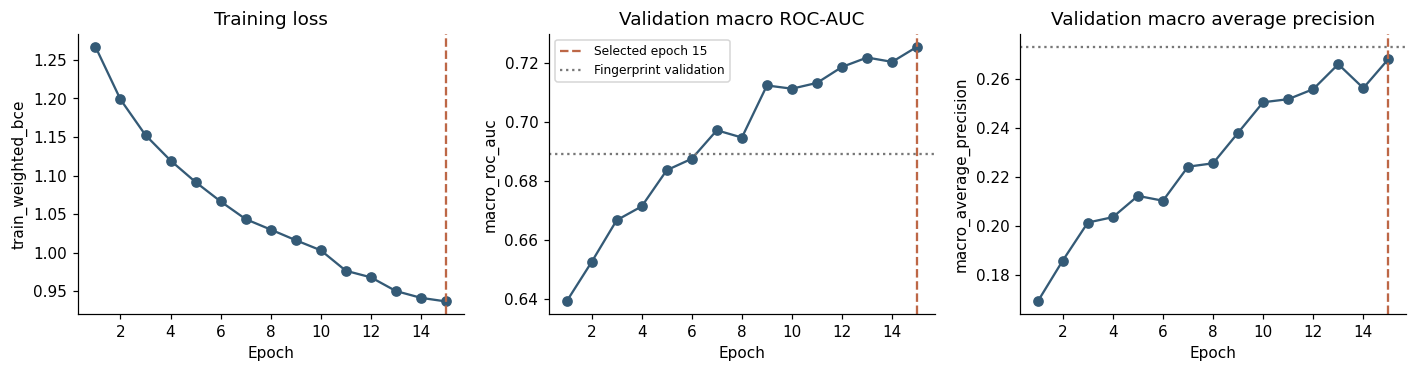

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for axis, metric, title in zip(axes, ['train_weighted_bce', 'macro_roc_auc', 'macro_average_precision'],
                             ['Training loss', 'Validation macro ROC-AUC', 'Validation macro average precision']):
    axis.plot(history['epoch'], history[metric], marker='o', color='#345a76')
    axis.axvline(best_epoch, color='#bd6746', linestyle='--', label=f'Selected epoch {best_epoch}')
    axis.set(title=title, xlabel='Epoch', ylabel=metric)
axes[1].axhline(baseline_val_table['roc_auc'].mean(), color='#777777', linestyle=':', label='Fingerprint validation')
axes[2].axhline(baseline_val_table['average_precision'].mean(), color='#777777', linestyle=':')
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 8. Evaluate the selected models on held-out scaffolds

The following comparison is produced after restoring the validation-selected GNN. Both learners use identical test rows and assay masks. The average-precision reference is test assay prevalence. Model selection has ended; these results are descriptive evaluation, not a signal for further tuning in this notebook.

In [15]:
baseline_test_probabilities = baseline_predict(test_idx)
gnn_test_probabilities = graph_predict(model, test_idx)
assert baseline_test_probabilities.shape == gnn_test_probabilities.shape == labels[test_idx].shape
assert np.isfinite(baseline_test_probabilities).all() and np.isfinite(gnn_test_probabilities).all()
baseline_test = evaluate_assays(labels[test_idx], baseline_test_probabilities)
gnn_test = evaluate_assays(labels[test_idx], gnn_test_probabilities)
summary = pd.DataFrame({'Morgan + logistic regression': macro_metrics(baseline_test),
                        'Message-passing GNN': macro_metrics(gnn_test)}).T
summary['selected_epoch'] = [np.nan, best_epoch]
display(summary.round(4))
results = baseline_test[['observed', 'positive', 'prevalence']].copy()
for prefix, table in [('fingerprint', baseline_test), ('gnn', gnn_test)]:
    results[prefix+'_roc_auc'] = table['roc_auc']
    results[prefix+'_AP'] = table['average_precision']
results['gnn_minus_fingerprint_roc'] = results['gnn_roc_auc'] - results['fingerprint_roc_auc']
display(results.round(4))
delta_roc = float(gnn_test['roc_auc'].mean() - baseline_test['roc_auc'].mean())
delta_ap = float(gnn_test['average_precision'].mean() - baseline_test['average_precision'].mean())
leader = 'GNN' if delta_roc > 0 else 'Morgan fingerprint baseline'
print(f'Finding: {leader} has the higher test macro ROC-AUC on this split. GNN minus baseline: ROC {delta_roc:+.4f}; AP {delta_ap:+.4f}.')

,macro_roc_auc,macro_average_precision,eligible_assays,selected_epoch
Morgan + logistic regression,0.6944,0.2707,12.0,NaN
Message-passing GNN,0.7449,0.3149,12.0,15.0


,observed,positive,prevalence,fingerprint_roc_auc,fingerprint_AP,gnn_roc_auc,gnn_AP,gnn_minus_fingerprint_roc
assay,,,,,,,,
NR-AR,704,29,0.0412,0.7956,0.4432,0.7776,0.4884,-0.0180
NR-AR-LBD,607,18,0.0297,0.8002,0.4617,0.9008,0.5829,0.1005
NR-AhR,601,90,0.1498,0.7814,0.3750,0.8524,0.5123,0.0710
NR-Aromatase,513,47,0.0916,0.6732,0.1669,0.7047,0.2100,0.0315
NR-ER,537,73,0.1359,0.6584,0.2614,0.7069,0.3372,0.0486
NR-ER-LBD,648,30,0.0463,0.7106,0.1725,0.7674,0.1862,0.0569
NR-PPAR-gamma,564,28,0.0496,0.6114,0.0955,0.6713,0.1009,0.0599
SR-ARE,489,106,0.2168,0.6426,0.3583,0.7114,0.3805,0.0688
SR-ATAD5,661,36,0.0545,0.6918,0.1444,0.7007,0.1365,0.0088


Finding: GNN has the higher test macro ROC-AUC on this split. GNN minus baseline: ROC +0.0505; AP +0.0442.


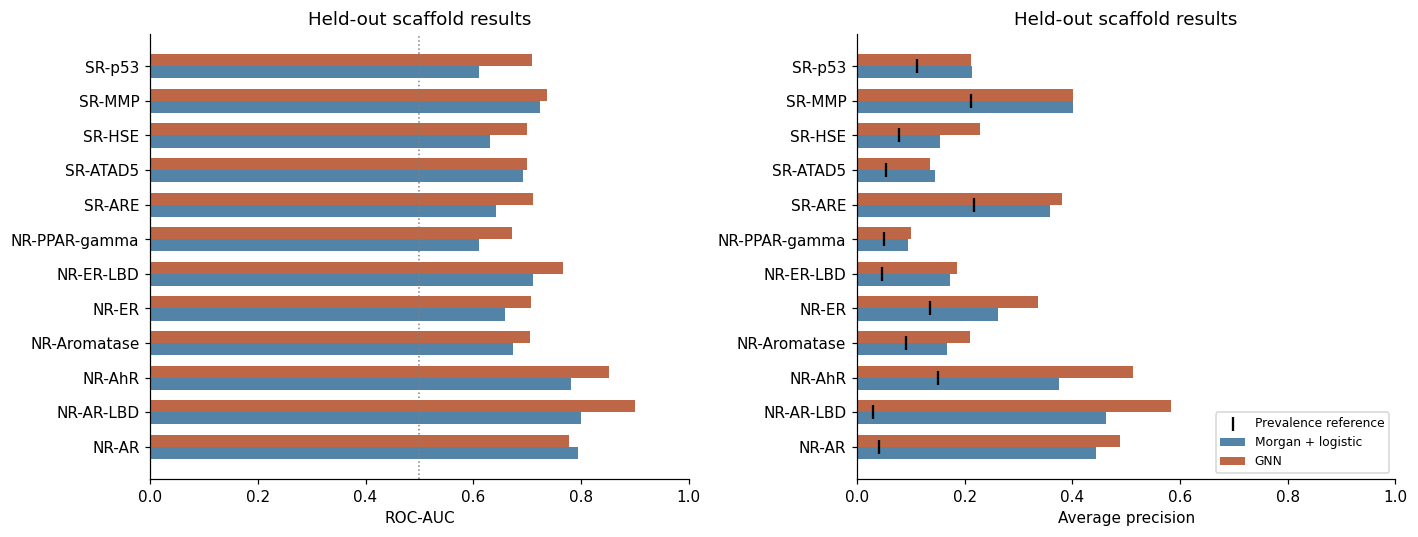

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ypos = np.arange(len(TASKS)); width = .35
for axis, metric, baseline_col, gnn_col in [(axes[0], 'ROC-AUC', 'fingerprint_roc_auc', 'gnn_roc_auc'),
                                           (axes[1], 'Average precision', 'fingerprint_AP', 'gnn_AP')]:
    axis.barh(ypos-width/2, results[baseline_col], height=width, color='#5483a8', label='Morgan + logistic')
    axis.barh(ypos+width/2, results[gnn_col], height=width, color='#bd6746', label='GNN')
    axis.set(yticks=ypos, yticklabels=TASKS, xlim=(0, 1), xlabel=metric, title='Held-out scaffold results')
axes[0].axvline(.5, color='gray', linestyle=':', linewidth=1)
axes[1].scatter(results['prevalence'], ypos, color='black', marker='|', s=95, label='Prevalence reference')
axes[1].legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()

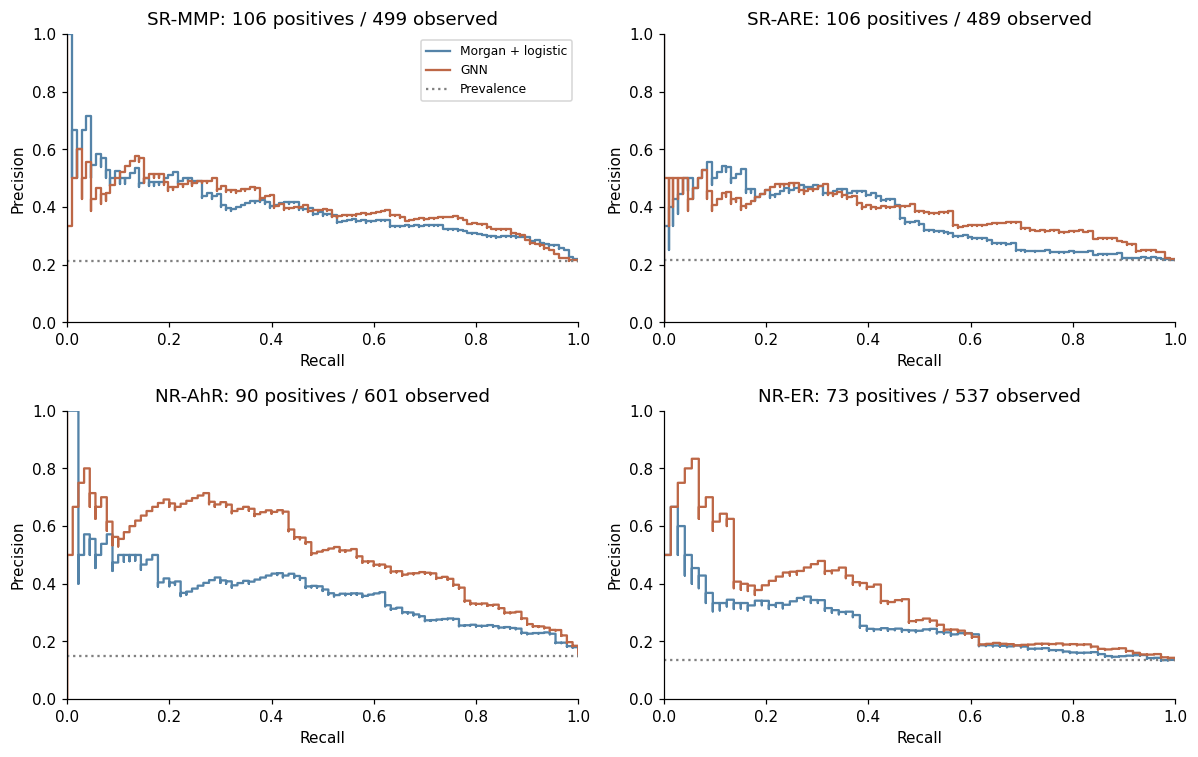

In [17]:
# Curves for four assays with the most observed test positives, chosen for readable descriptive plots.
curve_tasks = results.sort_values('positive', ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axis, task in zip(axes.flat, curve_tasks):
    task_index = TASKS.index(task)
    observed = np.isfinite(labels[test_idx, task_index])
    truth = labels[test_idx, task_index][observed]
    for name, predictions, color in [('Morgan + logistic', baseline_test_probabilities, '#5483a8'),
                                      ('GNN', gnn_test_probabilities, '#bd6746')]:
        precision, recall, _ = precision_recall_curve(truth, predictions[observed, task_index])
        axis.step(recall, precision, where='post', color=color, label=name)
    axis.axhline(truth.mean(), color='gray', linestyle=':', label='Prevalence')
    axis.set(title=f'{task}: {int(truth.sum())} positives / {len(truth)} observed',
             xlabel='Recall', ylabel='Precision', xlim=(0, 1), ylim=(0, 1))
axes.flat[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 9. Paired uncertainty over held-out scaffold families

The test set is finite and assay positives are sparse. A paired **scaffold-cluster bootstrap** resamples test scaffold groups with replacement and preserves every row and all assay labels within each sampled group. Both models receive the same resampled rows. This respects within-scaffold dependence better than treating every molecule as independent.

The interval measures sampling variability within this particular test scaffold collection. It does not include different training seeds, scaffold splits, feature choices, or systematic assay noise. Resamples missing a class for any originally eligible assay are skipped so the macro comparison keeps a constant assay set. The percentile interval is exploratory, not a claim of external validation.

In this particular largest-first split, every test scaffold contains one molecule, so the scaffold-cluster bootstrap is numerically a molecule bootstrap. The interval conditions on this fitted model and split; it does not cover variation from retraining or changing the split.


Paired scaffold-bootstrap macro ROC difference: +0.0505; 95% percentile interval [+0.0158, +0.0926]
Valid resamples: 300/300; test scaffold groups: 783


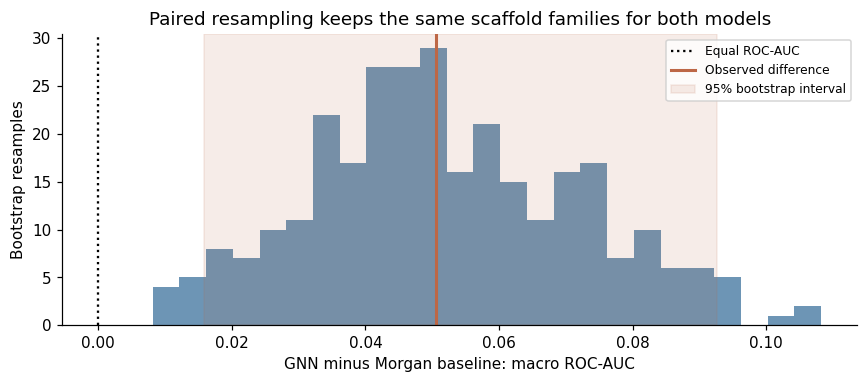

In [18]:
eligible_tasks = [i for i, task in enumerate(TASKS) if baseline_test.loc[task, 'roc_auc'] == baseline_test.loc[task, 'roc_auc']]
test_groups = defaultdict(list)
for test_position, global_row in enumerate(test_idx):
    test_groups[scaffolds[global_row]].append(test_position)
test_group_arrays = [np.array(rows, dtype=int) for rows in test_groups.values()]
rng = np.random.default_rng(SEED + 1)
bootstrap_deltas, attempted = [], 0
for _ in range(300):
    attempted += 1
    sampled_groups = rng.integers(0, len(test_group_arrays), size=len(test_group_arrays))
    sampled_rows = np.concatenate([test_group_arrays[i] for i in sampled_groups])
    y = labels[test_idx][sampled_rows]
    per_task_delta = []
    for task_index in eligible_tasks:
        mask = np.isfinite(y[:, task_index])
        truth = y[mask, task_index]
        if len(np.unique(truth)) != 2:
            break
        per_task_delta.append(roc_auc_score(truth, gnn_test_probabilities[sampled_rows, task_index][mask])
                              - roc_auc_score(truth, baseline_test_probabilities[sampled_rows, task_index][mask]))
    if len(per_task_delta) == len(eligible_tasks):
        bootstrap_deltas.append(np.mean(per_task_delta))
assert len(bootstrap_deltas) >= 100, 'Too few valid resamples to summarize uncertainty.'
lower_ci, upper_ci = np.percentile(bootstrap_deltas, [2.5, 97.5])
print(f'Paired scaffold-bootstrap macro ROC difference: {delta_roc:+.4f}; 95% percentile interval [{lower_ci:+.4f}, {upper_ci:+.4f}]')
print(f'Valid resamples: {len(bootstrap_deltas)}/{attempted}; test scaffold groups: {len(test_group_arrays)}')
plt.figure(figsize=(8, 3.6))
plt.hist(bootstrap_deltas, bins=25, color='#5483a8', alpha=.85)
plt.axvline(0, color='black', linestyle=':', label='Equal ROC-AUC')
plt.axvline(delta_roc, color='#bd6746', linewidth=2, label='Observed difference')
plt.axvspan(lower_ci, upper_ci, color='#bd6746', alpha=.12, label='95% bootstrap interval')
plt.xlabel('GNN minus Morgan baseline: macro ROC-AUC'); plt.ylabel('Bootstrap resamples')
plt.title('Paired resampling keeps the same scaffold families for both models')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. Inspect model sensitivity without claiming a toxicophore

An atom-level gradient can help inspect what a fitted graph network responds to. For an illustrative labeled test molecule, the next cell computes the magnitude of input-feature × gradient for the SR-MMP logit. Darker red atoms have greater local sensitivity in this model at this input. The example is chosen as the highest-scoring measured SR-MMP test molecule; it is descriptive and does not affect selection or metrics.

These gradients are not causal explanations or validated toxicophores. Discrete atom features cannot literally be varied continuously as the derivative assumes, and message passing can distribute sensitivity over several atoms. This plot is a debugging aid that would require stability tests, chemical counterfactuals, and experimental expertise before substantive use.

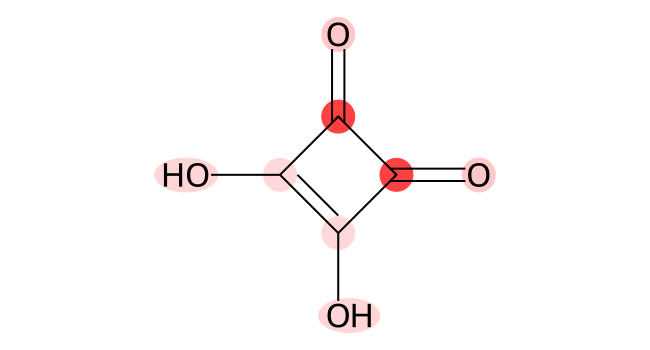

Illustration: TOX29369 | SR-MMP observed label=0 | GNN score=0.994


In [19]:
explain_task = 'SR-MMP'
task_index = TASKS.index(explain_task)
observed_positions = np.flatnonzero(np.isfinite(labels[test_idx, task_index]))
example_position = int(observed_positions[np.argmax(gnn_test_probabilities[observed_positions, task_index])])
example_row = int(test_idx[example_position])
example_batch = collate_graphs([example_row])
example_batch['x'] = example_batch['x'].clone().requires_grad_(True)
model.eval(); model.zero_grad(set_to_none=True)
example_logit = model(example_batch)[0, task_index]
example_logit.backward()
sensitivity = (example_batch['x'].grad * example_batch['x']).abs().sum(dim=1).detach().numpy()
sensitivity = sensitivity / max(float(sensitivity.max()), 1e-12)
atom_colors = {i: (1.0, float(1-.75*v), float(1-.75*v)) for i, v in enumerate(sensitivity)}
from IPython.display import Image as DisplayImage
drawer = Draw.rdMolDraw2D.MolDraw2DCairo(650, 350)
drawer.DrawMolecule(molecules[example_row], highlightAtoms=list(atom_colors),
                    highlightAtomColors=atom_colors, highlightBonds=[])
drawer.FinishDrawing()
display(DisplayImage(data=drawer.GetDrawingText()))
print(f"Illustration: {data.loc[example_row, 'mol_id']} | {explain_task} observed label={int(labels[example_row, task_index])} | GNN score={gnn_test_probabilities[example_position, task_index]:.3f}")

## 11. Interpret the outcome and its practical limits

The following conclusion is generated from the executed values. A graph architecture can learn useful local chemistry and still lose to a fingerprint classifier on a modest dataset. Hand-designed molecular fingerprints already encode strong domain knowledge; this small GNN has limited training data, a short receptive field, no stereochemical features, and no pretraining. Multi-task sharing can help related assays while transferring unhelpful signal between others.

The scaffold split is stricter than a random split, but one split and one training seed do not establish robust model superiority. Assay missingness may be informative, duplicate experimental rows remain, counterion removal changes some substances, and the largest-molecule exclusion narrows the evaluation domain. More rigorous follow-up would lock this benchmark, then use repeated scaffold splits, calibration on a separate validation set, richer stereochemical features, and external assay data. Those are future experiments, not explanations proven by this run.

In [20]:
relation = 'exceeds' if delta_roc > 0 else 'falls below'
uncertainty_text = ('The paired interval crosses zero, so this test collection does not resolve a direction.'
                    if lower_ci <= 0 <= upper_ci else
                    'The paired interval stays on one side of zero for these held-out scaffold groups; it does not include training or split variability.')
display(Markdown(f"""**Executed result.** The GNN test macro ROC-AUC is **{gnn_test['roc_auc'].mean():.3f}** and {relation} the Morgan baseline's **{baseline_test['roc_auc'].mean():.3f}** by **{abs(delta_roc):.3f}**. The respective macro average precisions are **{gnn_test['average_precision'].mean():.3f}** and **{baseline_test['average_precision'].mean():.3f}** across **{int(gnn_test['roc_auc'].notna().sum())}** eligible assays.

The validation-selected epoch is **{best_epoch}**. The paired scaffold-bootstrap ROC difference interval is **[{lower_ci:+.3f}, {upper_ci:+.3f}]**. {uncertainty_text}

**Decision:** this is evidence about ranking measured in-vitro assay activity on this Tox21 split. It is insufficient to determine human toxicity or clinical safety."""))

**Executed result.** The GNN test macro ROC-AUC is **0.745** and exceeds the Morgan baseline's **0.694** by **0.051**. The respective macro average precisions are **0.315** and **0.271** across **12** eligible assays.

The validation-selected epoch is **15**. The paired scaffold-bootstrap ROC difference interval is **[+0.016, +0.093]**. The paired interval stays on one side of zero for these held-out scaffold groups; it does not include training or split variability.

**Decision:** this is evidence about ranking measured in-vitro assay activity on this Tox21 split. It is insufficient to determine human toxicity or clinical safety.

## 12. Final audit and reproducibility record

The manifest below binds the data bytes, row split, preprocessing policy, model settings, selected epoch, software versions, and observed results. All figures and tables were computed by the cells above. Data and models are recreated on rerun; no local checkpoint is needed. The notebook is the complete published artifact.

In [21]:
assert set(train_idx).isdisjoint(val_idx) and set(train_idx).isdisjoint(test_idx) and set(val_idx).isdisjoint(test_idx)
assert all(np.isfinite(v) for v in [delta_roc, delta_ap, lower_ci, upper_ci])
assert not any(scaffold_sets[a] & scaffold_sets[b] for a, b in [('train','validation'),('train','test'),('validation','test')])
# A missing target's gradient is exactly zero after applying the mask.
probe_logits = torch.zeros((1, len(TASKS)), requires_grad=True)
probe_targets = torch.zeros_like(probe_logits)
probe_mask = torch.tensor([[False] + [True] * (len(TASKS)-1)])
(criterion(probe_logits, probe_targets) * probe_mask).sum().backward()
assert probe_logits.grad[0, 0].item() == 0
manifest = {'data': provenance, 'split_sha256': split_digest, 'seed': SEED,
            'preprocessing': qc, 'scaffold_split': split_summary['rows'].to_dict(),
            'baseline': {'representation': 'Morgan radius2 bits2048', 'model': 'balanced LogisticRegression C=1'},
            'gnn': {'hidden': 48, 'depth': 3, 'batch_size': 96, 'max_epochs': MAX_EPOCHS,
                    'patience': PATIENCE, 'selected_epoch': best_epoch, 'threads': 2},
            'test_macro_metrics': summary.drop(columns='selected_epoch').to_dict(orient='index'),
            'paired_scaffold_bootstrap_roc_difference_95pct': [float(lower_ci), float(upper_ci)],
            'versions': versions}
print(json.dumps(manifest, indent=2))
print('Final audit passed: real pinned data, exhaustive row partition, scaffold disjointness, matching test masks, and zero missing-label gradient verified.')

{
  "data": {
    "source_url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz",
    "sha256": "45d09792492ce049039dd24aa27b07fc79ce20c573187d4d90bcd178c0c0d360",
    "compressed_bytes": 122925,
    "raw_rows": 7831,
    "endpoints": 12
  },
  "split_sha256": "e6ac489f02cf2d3d694447b61e02a453a0a74ff6686e6765abef90b1e9f9cd9e",
  "seed": 42,
  "preprocessing": {
    "retained_rows": 7816,
    "excluded_rows": {
      "zero_or_over_100_heavy_atoms": 7,
      "invalid_or_unsanitizable_smiles": 8
    },
    "disconnected_rows_encountered": 244,
    "retained_duplicate_structure_rows": 115,
    "largest_retained_heavy_atom_count": 100
  },
  "scaffold_split": {
    "train": 6252,
    "validation": 781,
    "test": 783
  },
  "baseline": {
    "representation": "Morgan radius2 bits2048",
    "model": "balanced LogisticRegression C=1"
  },
  "gnn": {
    "hidden": 48,
    "depth": 3,
    "batch_size": 96,
    "max_epochs": 15,
    "patience": 4,
    "selected_epoch": 15

## References

1. Wu et al. (2018). *MoleculeNet: a benchmark for molecular machine learning.* [Chemical Science](https://doi.org/10.1039/C7SC02664A).
2. Bemis & Murcko (1996). *The properties of known drugs. 1. Molecular frameworks.* [Journal of Medicinal Chemistry](https://doi.org/10.1021/jm9602928).
3. Gilmer et al. (2017). *Neural Message Passing for Quantum Chemistry.* [arXiv:1704.01212](https://arxiv.org/abs/1704.01212).
4. [RDKit documentation](https://www.rdkit.org/docs/) and [PyTorch documentation](https://pytorch.org/docs/stable/).
5. [NIH Tox21 program](https://ncats.nih.gov/research/research-activities/tox21) and the [exact public data artifact](https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz).